# Analysis test - modified correlation with the library
Calculate best correlation match with (arithmetic modification) of Gabor filter library decomposed visual stimulation. 

Puts output in dedicated folder.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import json
import pandas as pd
import pickle

from wavelet_utils_vSpeed import loadFilterParamDict_vS, makeFilterParamDict_vS, saveFilterParamDict_vS, filename_fromFilterParam, compute_and_save_dwt_vS, get_filter_from_params, get_filter_vector
from analysis_utils import compute_respcorr_split_half, FeatureSearch_correlation_batched, fit_sine1x, sine1x, dwt_amp_phase_torch_batched, gaussian_filter1d_torch_axis0_chunked

In [2]:
#jobFolder_str=r"GBM11\g11_0409_zebra"
#jobFolder_str=r"GBM11\g11_0409_zebra5"
#jobFolder_str=r"GBM11\g11_0415_zebra5"
#jobFolder_str=r"GBM11\g11_0423_zebra6"
#jobFolder_str=r"GBM11\g11_0508_full"
jobFolder_str=r"GBM11\g11_0603_r2_z225"
#jobFolder_str=r"GBM11\g11_0603_r2_z185"
#jobFolder_str=r"GBM11\g11_0603_r2_z265"
#jobFolder_str=r"GBM11\g11_0605_r2_z225"
#jobFolder_str=r"GBM11\g11_0605_r2_z225LS"
#jobFolder_str=r"GBM11\g11_0605_r2_z225US"

#jobFolder_str=r"GBM15\g15_0408_zebra"
#jobFolder_str=r"GBM15\g15_0422_zebra3"

In [3]:
spks_path = "D:\\SynologyDriveSyncedDATA\\PROCESSED\\GBM\\" +  jobFolder_str + "\\ZEBRA_ANALYSIS\\resps_all.npy"

if Path(spks_path).exists():   print(spks_path)
else: print(f"File not found: {spks_path}")

metadata={}
metadata["spks_path"] = spks_path

D:\SynologyDriveSyncedDATA\PROCESSED\GBM\GBM11\g11_0603_r2_z225\ZEBRA_ANALYSIS\resps_all.npy


In [4]:
full_screen_coverage = [-88, 0, -33, 33] # [az_left, az_right, el_bottom, el_top] full screen position in visual degrees
visual_coverage = [-88, 0, -33, 33] # [az_left, az_right, el_bottom, el_top] screen coverage in visual degrees (seen by the animal)

screen_x = 100 # horizontal screen size in pixels for the Gabor filter generation and movie analysis
screen_t = 3 # time dimension of the screen in pixels

nx = 16 # number of Gabor filters in the horizontal direction (azimuth) (y will be generated)
        # 40 is a good number. Use 5 for testing to make it fast
        
n_thetas = 8 # number of angles to generate

size_min = 4 # minimum size in visual degrees
size_max = 20 # maximum size in visual degrees
n_sizes = 6   # number of sizes to generate

freq_min = .025 # minimum frequency in cycles per visual degree
freq_max = .15 # maximum frequency in cycles per visual degree
n_freqs = 5  # number of frequencies to generate

n_phases = 4  # number of phases to generate
phase_max = np.pi*2 # maximum phase to generate

driftmax=4 # maximum drift speed in degrees per frame
driftnum=3 # 2n+1 drift speeds will be generated

In [5]:
#calculations
az_left, az_right, el_bottom, el_top = visual_coverage

screen_y = int(screen_x * (el_top - el_bottom) / (az_right - az_left))
ny = int(nx * (el_top - el_bottom) / (az_right - az_left))

# centers in visual degrees
xs = np.linspace(az_left, az_right, nx, endpoint=False)+(az_right - az_left) / (2*nx)
ys = np.linspace(el_bottom, el_top, ny, endpoint=False)+(el_top - el_bottom) / (2*ny)

angles= np.linspace(0, np.pi, n_thetas, endpoint=False)
sizes = np.logspace(np.log10(size_min), np.log10(size_max), n_sizes)
freqs = np.logspace(np.log10(freq_min), np.log10(freq_max), n_freqs)
phases = np.linspace(0,  phase_max, n_phases, endpoint=False)
drifts=np.linspace(-driftmax, driftmax, driftnum*2+1)

print(f"Screen size: {screen_x}x{screen_y} pixels")
print(f"Full screen coverage: {full_screen_coverage} degrees")
print(f"Visual coverage: {visual_coverage} degrees")
#print(f"Center positions (x_deg): {np.round(xs, 1)} degrees")
#print(f"Center positions (y_deg): {np.round(ys, 1)} degrees")
print(f"Angles (degrees): {np.round(np.rad2deg(angles), 1)}")
print(f"Sizes (degrees): {sizes}")
print(f"Frequencies (cycles/degree): {freqs}")
print(f"Phases (degrees): {np.rad2deg(phases)}")
print(f"Drifts (degrees/frame): {drifts}")

Screen size: 100x75 pixels
Full screen coverage: [-88, 0, -33, 33] degrees
Visual coverage: [-88, 0, -33, 33] degrees
Angles (degrees): [  0.   22.5  45.   67.5  90.  112.5 135.  157.5]
Sizes (degrees): [ 4.          5.51891865  7.61461575 10.50611122 14.49559327 20.        ]
Frequencies (cycles/degree): [0.025      0.03912711 0.06123724 0.09584147 0.15      ]
Phases (degrees): [  0.  90. 180. 270.]
Drifts (degrees/frame): [-4.         -2.66666667 -1.33333333  0.          1.33333333  2.66666667
  4.        ]


In [6]:
total_n=len(sizes)*len(angles)*len(freqs)*len(drifts)*len(phases)*len(xs)*len(ys)
print(f"Total number of Gabor filters to generate: {total_n}")

Total number of Gabor filters to generate: 1290240


In [7]:
gabor_step=(az_right-az_left)/nx 
print(f"Control: Gabor placement step in visual degrees (x): {gabor_step:.1f}, vs size_min: {size_min:.1f} degrees. {'OK' if (gabor_step < size_min) else 'WARNING!'}")
gabor_step=(el_top-el_bottom)/ny
print(f"Control: Gabor placement step in visual degrees (y): {gabor_step:.1f}, vs size_min: {size_min:.1f} degrees. {'OK' if (gabor_step < size_min) else 'WARNING!'}")
visual_step_x=(az_right-az_left)/screen_x
print(f"Control: Gabor resolution in visual degrees (x): {visual_step_x:.1f}, vs 1/freq_max: {1/freq_max:.1f} degrees. {'OK' if (visual_step_x < 1/freq_max/4) else 'WARNING!'}")
visual_step_y=(el_top-el_bottom)/screen_y
print(f"Control: Gabor resolution in visual degrees (y): {visual_step_y:.1f}, vs 1/freq_max: {1/freq_max:.1f} degrees. {'OK' if (visual_step_y < 1/freq_max/4) else 'WARNING!'}")

wavelet_params=makeFilterParamDict_vS(screen_x, screen_y, screen_t, visual_coverage, full_screen_coverage, xs, ys, angles, sizes, freqs, drifts, phases)
metadata["wavelet_params"] = wavelet_params

Control: Gabor placement step in visual degrees (x): 5.5, vs size_min: 4.0 degrees. WARNING!
Control: Gabor placement step in visual degrees (y): 5.5, vs size_min: 4.0 degrees. WARNING!
Control: Gabor resolution in visual degrees (x): 0.9, vs 1/freq_max: 6.7 degrees. OK
Control: Gabor resolution in visual degrees (y): 0.9, vs 1/freq_max: 6.7 degrees. OK


In [8]:
# Video to analyze
temppath = r'D:\SynologyDriveSyncedDATA\PROCESSED\Waven'
downsampled_video_path = Path(temppath) / r"zebra_s0_d420.0_fps59.94_RESAMPLED30fps_scaled100x75.npy"

_, paramname = filename_fromFilterParam(wavelet_params)
paramspath = downsampled_video_path.parent / paramname
saveFilterParamDict_vS(wavelet_params, paramspath)
print(f"Saved Gabor filter parameters to {paramspath}")


Saved Gabor filter parameters to D:\SynologyDriveSyncedDATA\PROCESSED\Waven\gaborLibrary_vS_16_12_8_6_5_7_4_ca696278.json


## Calculate DWT if not already done

In [9]:
dwt_path=compute_and_save_dwt_vS(downsampled_video_path, wavelet_params,   device='cuda', force=False)
if Path(dwt_path).exists():   print(dwt_path)
else: print(f"File not found: {dwt_path}")

Loaded downsampled video data from D:\SynologyDriveSyncedDATA\PROCESSED\Waven\zebra_s0_d420.0_fps59.94_RESAMPLED30fps_scaled100x75.npy with shape (12600, 100, 75) and dtype bool
||Constructing: zebra_s0_d420.0_fps59.94_RESAMPLED30fps_scaled100x75_libvS_16_12_8_6_5_7_4_ca696278dwt.npy 
Wavelet transform file D:\SynologyDriveSyncedDATA\PROCESSED\Waven\zebra_s0_d420.0_fps59.94_RESAMPLED30fps_scaled100x75_libvS_16_12_8_6_5_7_4_ca696278dwt.npy already exists. Skipping computation.
D:\SynologyDriveSyncedDATA\PROCESSED\Waven\zebra_s0_d420.0_fps59.94_RESAMPLED30fps_scaled100x75_libvS_16_12_8_6_5_7_4_ca696278dwt.npy


In [10]:
xs, ys, angles, sizes, freqs, drifts,  phases, visual_coverage, full_screen_coverage, screen_t, screen_x, screen_y = loadFilterParamDict_vS(paramspath)

## Load spike data

In [11]:
spks=np.load(spks_path)
print(f"spks shape: {spks.shape} (n_trials, n_timepoints, n_neurons)")
n_trials=spks.shape[0]
n_timepoints=spks.shape[1]
n_neurons=spks.shape[2]


## converts neuron position in microns
#neuron_pos=np.load(working_dir / 'component_centers.npy')
#neuron_pos=correctNeuronPos(neuron_pos, resolution)
#print(f"neuron_pos shape: {neuron_pos.shape}")

spks shape: (3, 12600, 2070) (n_trials, n_timepoints, n_neurons)


In [12]:
# Gauss averaging along dimension 1 with set FWHM (target_fps=30)
from scipy.ndimage import gaussian_filter1d
target_fps = 30

average_FWHM_sec = 0.1 #sec
average_FWHM_samples = int(np.round(target_fps * average_FWHM_sec))

shift_samples = 1 # shift by 1 sample to account for the calcium bindingdelay of the dye

if average_FWHM_samples > 0:
    spks = gaussian_filter1d(spks, sigma=average_FWHM_samples / 2.355,  axis=1)
if shift_samples != 0:
    spks = np.roll(spks, -shift_samples, axis=1)
print(f"spks shape: {spks.shape} (n_trials, n_timepoints, n_neurons), smoothed by {average_FWHM_samples} samples, shifted forward by {shift_samples} samples")

mean_spks = np.mean(spks[:, :, :], axis=0)

working_dir = Path(spks_path).parent
print(f"Working directory: {working_dir}")

metadata["shift_samples"] = shift_samples

spks shape: (3, 12600, 2070) (n_trials, n_timepoints, n_neurons), smoothed by 3 samples, shifted forward by 1 samples
Working directory: D:\SynologyDriveSyncedDATA\PROCESSED\GBM\GBM11\g11_0603_r2_z225\ZEBRA_ANALYSIS


## Correlate neural data with decomposed stimulus

In [13]:
# load dwt
dwt = np.load(dwt_path)
print(f"dwt shape: {dwt.shape}")

dwt shape: (12600, 16, 12, 8, 6, 5, 7, 4)


In [14]:
# modify dwt
mode=2
 
if mode==0: # no modification
    comment='orig'
elif mode==1: # restrict dwt to >0
    comment='Gt0'
    dwt[dwt < 0] = 0
elif mode==2: # take absolute value
    comment='abs'
    dwt=np.abs(dwt)  
elif mode==4: # complex
    if len(phases)!=2:
        raise ValueError("For complex representation, n_phases must be 2.")
    comment='complex'
    #Calculating  amplitude and phase from the two phase DWT  
    dwt, _ =dwt_amp_phase_torch_batched(dwt) #drop phase for now
    # drops last feature dimension: phase
feature_dim_number=len(dwt.shape)-1

if average_FWHM_samples > 0:
    #dwt_mod = gaussian_filter1d(dwt_mod, sigma=average_FWHM_samples / 2.355,  axis=0)
    dwt = gaussian_filter1d_torch_axis0_chunked(dwt, average_FWHM_samples / 2.355)
    
print(f"Using dwt mode: {comment}, feature dimension number: {feature_dim_number}")

metadata["dwt_mode"] = comment
metadata["feature_dim_number"] = feature_dim_number

    Torch using: cuda, GPU index: 0, GPU name: NVIDIA GeForce RTX 4070 SUPER


Gaussian smoothing: 100%|██████████| 65/65 [02:47<00:00,  2.57s/it]


Using dwt mode: abs, feature dimension number: 7


## Splitting data

In [15]:
#defining train and test data parts
train_test=True #whether to split data in train and test set, if False use all data for training and no test evaluation
train_split=0.85 #split ratio in time if train_test

if train_test:
    train_split_index=int(n_timepoints*train_split)
else:
    train_split_index=n_timepoints

print(f"Train split at {train_split_index/n_timepoints*100:.1f}% of timepoints, test split at {((1-train_split_index/n_timepoints)*100):.1f}% of timepoints")

metadata["train_split"] = train_split
metadata["train_split_index"] = train_split_index

Train split at 85.0% of timepoints, test split at 15.0% of timepoints


In [16]:
## runs correlation analysis


rfs = FeatureSearch_correlation_batched(dwt[:train_split_index], mean_spks[:train_split_index])


    stim_flat shape: (10710, 1290240) (n_timepoints=10710, n_features=1290240)
    resp shape: (10710, 2070) (n_timepoints=10710, n_neurons=2070)
    Torch using: cuda, GPU index: 0, GPU name: NVIDIA GeForce RTX 4070 SUPER


Pearson RF feature batches: 100%|██████████| 130/130 [00:43<00:00,  2.97it/s]


| Torch (cuda:0) tensor memory usage:
| ------------------------------------------------------------
| R                   :    84.57 MB  | shape=(2070, 10710)  dtype=torch.float32
| S_chunk             :     9.81 MB  | shape=(240, 10710)  dtype=torch.float32
| rfs_chunk           :     1.90 MB  | shape=(2070, 240)  dtype=torch.float32
| ------------------------------------------------------------
| TENSORS:    96.27 MB (  0.8%) | RESERVED:  1814.00 MB ( 14.8%) | TOTAL GPU: 12281.50 MB  
    output shape: (2070, 16, 12, 8, 6, 5, 7, 4) (neurons=2070, feature_dims=(16, 12, 8, 6, 5, 7, 4))


## Analyze results

In [17]:
output_folder = working_dir / (paramname.replace('.json', '')+f"_{comment}")
output_folder.mkdir(exist_ok=True)
saveFilterParamDict_vS(wavelet_params, output_folder / paramname)  # save a copy in the output folder 
print(f"Saved Gabor filter parameters to {output_folder}")

Saved Gabor filter parameters to D:\SynologyDriveSyncedDATA\PROCESSED\GBM\GBM11\g11_0603_r2_z225\ZEBRA_ANALYSIS\gaborLibrary_vS_16_12_8_6_5_7_4_ca696278_abs


In [18]:
respcorr = compute_respcorr_split_half(spks)

# top 3 most repeatable neurons
top_neurons = np.argsort(respcorr)[-3:]
print(f"Top 3 most repeatable neurons: {top_neurons}")

Computing split-half correlation per neuron: 100%|██████████| 2070/2070 [00:02<00:00, 965.21it/s] 

Top 3 most repeatable neurons: [ 143  619 1568]


In [19]:
# fit angle tuning curve: sine
tuning_angles_fit=[]
for _idx in range(n_neurons):
    myrfs = rfs[_idx]
    max_idx = np.unravel_index(np.argmax(myrfs), myrfs.shape)
    max_idx = tuple(int(i) for i in max_idx)
    tuning_curve_raw = myrfs[max_idx[0], max_idx[1], :, *max_idx[3:feature_dim_number]]
    
    sin_params = fit_sine1x(angles, tuning_curve_raw)

    # interpolated fit
    angles_interp = np.linspace(0, 1*np.pi, 100)
    tuning_curve_fit_interp = sine1x(angles_interp, **sin_params)
    
    tuning_angles_fit.append((sin_params, angles_interp, tuning_curve_fit_interp))
    

In [20]:
#play: # find absolut maximum RF value across all neurons and features
max_idx = np.unravel_index(np.argmax(rfs), rfs.shape)
max_idx = tuple(int(i) for i in max_idx)
max_value = rfs[max_idx]
print(f"max RF value: {max_value} at index {max_idx}")

max RF value: 0.6111388206481934 at index (755, 10, 9, 7, 3, 3, 3, 0)


In [21]:
#play: # find maximum RF value for a specific neuron
my_neuron = 456
# my_neuron = 1813 

myrfs = rfs[my_neuron]
max_idx = np.unravel_index(np.argmax(myrfs), myrfs.shape)
max_idx = tuple(int(i) for i in max_idx)
max_value = myrfs[max_idx]
print(f"Neuron {my_neuron} max RF value: {max_value:.3f} at index {max_idx}, respcorr: {respcorr[my_neuron]:.3f}")

Neuron 456 max RF value: 0.278 at index (9, 10, 6, 3, 4, 3, 0), respcorr: 0.625


In [22]:
# find maximum RF value for each neuron (train performance) and compute test correlation
r_train = np.zeros(n_neurons) # correlation of train data at the best RF prediction
r_test = np.zeros(n_neurons) # correlation of test data at the best RF prediction
max_idxs = np.zeros((n_neurons, len(rfs.shape)-1), dtype=int) # store the RF index of the best RF for each neuron

for i in range(n_neurons):
    myrfs = rfs[i]
    max_idx = np.unravel_index(np.argmax(myrfs), myrfs.shape)
    max_idx = tuple(int(ij) for ij in max_idx)
    max_idxs[i] = max_idx
    r_train[i] = myrfs[max_idx] # this equals to np.corrcoef(mean_spks[:train_split_index, i], dwt_squared[:train_split_index, *max_idx])[0, 1]
    r_test[i] = np.corrcoef(mean_spks[train_split_index:, i], dwt[train_split_index:, *max_idx])[0, 1]


In [23]:
# save respcorr and max_values for each neuron to a csv file

df = pd.DataFrame({'respcorr': respcorr, 'r_train': r_train, 'r_test': r_test})
df.to_csv(output_folder / 'respcorr_max_values_vs4.csv', index=False)

In [24]:
#play: #index of largest 20 respcorr values
largest_respcorr_indices = np.argsort(respcorr)[-20:]
print(f"Mean respcorr of largest 20 neurons: {np.mean(respcorr[largest_respcorr_indices]):.3f}")
print(f"Mean rfs_correlation of largest 20 neurons (train performance): {np.mean(r_train[largest_respcorr_indices]):.3f}")
print(f"Mean rfs_correlation of largest 20 neurons (test performance): {np.mean(r_test[largest_respcorr_indices]):.3f}")
stat={}
stat['N_xs'] = len(xs)
stat['N_ys'] = len(ys)
stat['N_angles'] = len(angles)
stat['N_sizes'] = len(sizes)
stat['N_freqs'] = len(freqs)
stat['N_drifts'] = len(drifts)
stat['N_phases'] = len(phases)
stat['average_FWHM_samples'] = average_FWHM_samples
stat['shift_samples'] = shift_samples
stat['mode'] = comment
stat['mean_respcorr_top20'] = np.mean(respcorr[largest_respcorr_indices])
stat['mean_r_train_top20'] = np.mean(r_train[largest_respcorr_indices])
stat['mean_r_test_top20'] = np.mean(r_test[largest_respcorr_indices])

Mean respcorr of largest 20 neurons: 0.618
Mean rfs_correlation of largest 20 neurons (train performance): 0.297
Mean rfs_correlation of largest 20 neurons (test performance): 0.198


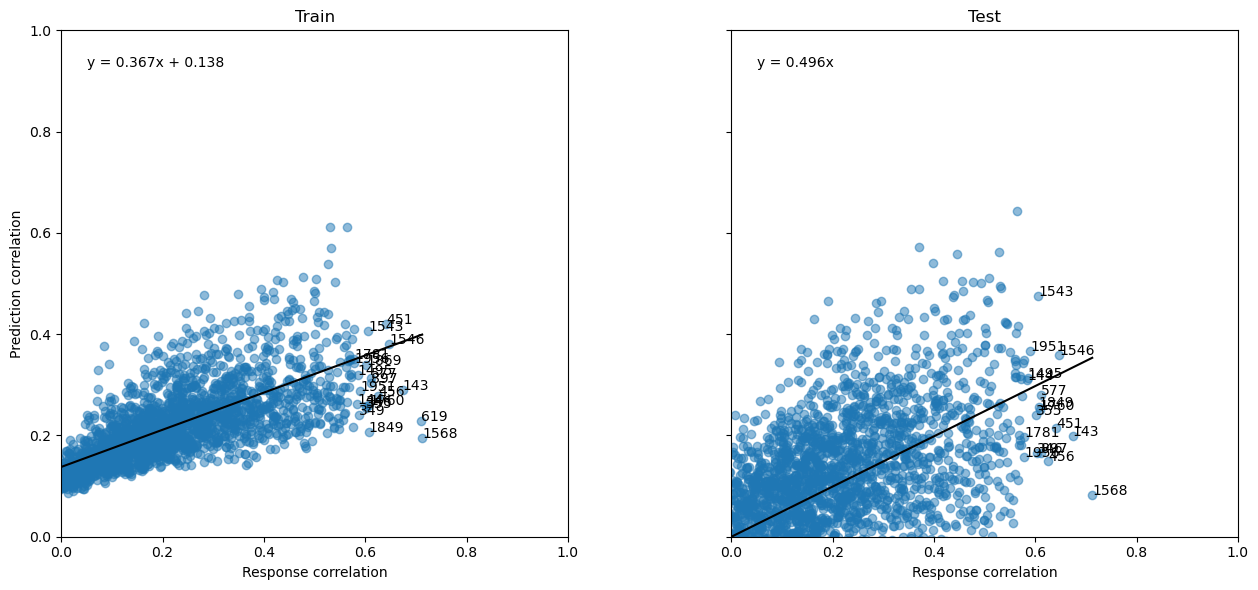

train fit: y = 0.366806 x + 0.137935
test fit : y = 0.495954 x


In [25]:
# plot neuron prediction correlation.

fig, axes = plt.subplots( 1, 2,  figsize=(14, 6),  sharex=True,  sharey=True )

# ---------- left: r_train ----------
ax = axes[0]
ax.scatter(respcorr, r_train, alpha=0.5)

for i in largest_respcorr_indices:
    ax.annotate(f"{i}", (respcorr[i], r_train[i]))

mask = np.isfinite(respcorr) & np.isfinite(r_train)
a_train, b_train = np.polyfit(respcorr[mask], r_train[mask], 1)
xx = np.linspace(np.nanmin(respcorr), np.nanmax(respcorr), 200)
ax.plot(xx, a_train * xx + b_train, color='black')

ax.text( 0.05, 0.95, f"y = {a_train:.3f}x + {b_train:.3f}",  transform=ax.transAxes,  va="top")

ax.set_title("Train")
ax.set_xlabel("Response correlation")
ax.set_ylabel("Prediction correlation")
ax.set_aspect('equal', adjustable='box')
ax.set_ylim(0, 1)
ax.set_xlim(0, 1)

# ---------- right: r_test ----------
ax = axes[1]
ax.scatter(respcorr, r_test, alpha=0.5)

for i in largest_respcorr_indices:
    ax.annotate(f"{i}", (respcorr[i], r_test[i]))

mask = np.isfinite(respcorr) & np.isfinite(r_test)

# constrained through origin
a_test = np.sum(respcorr[mask] * r_test[mask]) / np.sum(respcorr[mask] ** 2)
ax.plot(xx, a_test * xx, color='black')

ax.text(0.05, 0.95, f"y = {a_test:.3f}x", transform=ax.transAxes,  va="top")

ax.set_title("Test")
ax.set_xlabel("Response correlation")
ax.set_aspect('equal', adjustable='box')


plt.tight_layout()
plt.savefig(output_folder / 'respcorr_vs_prediction_correlation_5.png', dpi=300)
plt.show()

print(f"train fit: y = {a_train:.6f} x + {b_train:.6f}")
print(f"test fit : y = {a_test:.6f} x")


In [26]:
stat['train_fit_a'] = a_train
stat['train_fit_b'] = b_train
stat['test_fit_a'] = a_test
metadata['stat'] = stat

In [27]:
#save results into cell database
input_pickle_path= working_dir / "cells_caiman.cellDB_pickle"
if input_pickle_path.exists():
    with open(input_pickle_path, "rb") as f:
        df_cells = pickle.load(f)  # First object (DataFrame)
        my_dict = pickle.load(f)   # Second object (Dictionary)
else:
    df_cells = pd.DataFrame()
    for _idx in range(n_neurons): #handling only good components
            record={}
            record['cell_id'] = _idx
            record['SeriesID'] = 'unknown'
            df_cells = pd.concat([df_cells, pd.DataFrame([record])], ignore_index=True)
    my_dict = {}

metadata = my_dict | metadata # merge the loaded dictionary with the new metadata, giving precedence to the new metadata in case of key conflicts

df_cells = df_cells.set_index("cell_id", drop=False)

df_cells["RF_indexes"] = pd.Series([None] * len(df_cells), dtype="object")
df_cells["WL_transient_mod"] = pd.Series([None] * len(df_cells), dtype="object")
#df_cells["WL_transient_phase"] = pd.Series([None] * len(df_cells), dtype="object")
df_cells["Cell_activity"] = pd.Series([None] * len(df_cells), dtype="object")
df_cells["tun_xs"] = pd.Series([None] * len(df_cells), dtype="object")
df_cells["tun_ys"] = pd.Series([None] * len(df_cells), dtype="object")
df_cells["tun_xy"] = pd.Series([None] * len(df_cells), dtype="object")
df_cells["tun_angles"] = pd.Series([None] * len(df_cells), dtype="object")
df_cells["tun_sizes"] = pd.Series([None] * len(df_cells), dtype="object")
df_cells["tun_freqs"] = pd.Series([None] * len(df_cells), dtype="object")
df_cells["tun_drifts"] = pd.Series([None] * len(df_cells), dtype="object")
if feature_dim_number>6:
    df_cells["tun_phases"] = pd.Series([None] * len(df_cells), dtype="object")


for _idx in tqdm(range(n_neurons)):
    df_cells.loc[_idx,'Repeatability'] = respcorr[_idx]
    
    max_idx = max_idxs[_idx] # use pre-stored max idx for consistency with interactive view
    
    df_cells.at[_idx, 'RF_indexes'] = [int(ij) for ij in max_idx] # store the RF index of the best RF for each neuron as a list
    df_cells.loc[_idx, 'r_train'] = r_train[_idx]
    df_cells.loc[_idx, 'r_test'] = r_test[_idx]
    
    df_cells.loc[_idx, 'Azimuth'] = xs[max_idx[0]]
    df_cells.loc[_idx, 'Elevation'] = ys[max_idx[1]]
    df_cells.loc[_idx, 'Angle'] = angles[max_idx[2]]
    df_cells.loc[_idx, 'Size'] = sizes[max_idx[3]]
    df_cells.loc[_idx, 'Frequency'] = freqs[max_idx[4]]
    df_cells.loc[_idx, 'Drift'] = drifts[max_idx[5]]
    if feature_dim_number>6:
        df_cells.loc[_idx, 'Phase'] = phases[max_idx[6]]


    transient_mod = dwt[:, *max_idx]
    
    df_cells.at[_idx, 'WL_transient_mod'] = transient_mod
    df_cells.at[_idx, 'Cell_activity'] = spks[:, :, _idx]
    
    #store tuning curves
    myrfs = rfs[_idx]
    df_cells.at[_idx, 'tun_xs'] = myrfs[:, max_idx[1], max_idx[2], max_idx[3], *max_idx[4:feature_dim_number]]
    df_cells.at[_idx, 'tun_ys'] = myrfs[max_idx[0], :, max_idx[2], max_idx[3], *max_idx[4:feature_dim_number]]
    df_cells.at[_idx, 'tun_xy'] = myrfs[:, :, max_idx[2], max_idx[3], *max_idx[4:feature_dim_number]]
            
    df_cells.at[_idx, 'tun_angles'] = myrfs[max_idx[0], max_idx[1], :, max_idx[3], *max_idx[4:feature_dim_number]]
    df_cells.at[_idx, 'tun_sizes'] = myrfs[max_idx[0], max_idx[1], max_idx[2], :, *max_idx[4:feature_dim_number]]
    df_cells.at[_idx, 'tun_freqs'] = myrfs[max_idx[0], max_idx[1], max_idx[2], max_idx[3], :, *max_idx[5:feature_dim_number]]
    if feature_dim_number>6:
        df_cells.at[_idx, 'tun_drifts'] = myrfs[max_idx[0], max_idx[1], max_idx[2], max_idx[3], max_idx[4], :, *max_idx[6:feature_dim_number]]
        df_cells.at[_idx, 'tun_phases'] = myrfs[max_idx[0], max_idx[1], max_idx[2], max_idx[3], max_idx[4], max_idx[5], :]
    else:
        df_cells.at[_idx, 'tun_drifts'] = myrfs[max_idx[0], max_idx[1], max_idx[2], max_idx[3], max_idx[4], :]
        
    #store angle fit
    sin_params, x_fit, y_fit = tuning_angles_fit[_idx]
    df_cells.loc[_idx, 'Angle_fit_ori'] = sin_params['orientation']
    df_cells.loc[_idx, 'Angle_fit_amplitude'] = sin_params['amplitude']
    df_cells.loc[_idx, 'Angle_fit_constant'] = sin_params['constant']
    df_cells.loc[_idx, 'Angle_fit_OSI'] = sin_params['amplitude'] / (sin_params['amplitude'] + sin_params['constant'])

picles_path=output_folder / "cells_waven1vs.cellDB_pickle"

with open(picles_path, 'wb') as f:
    pickle.dump(df_cells, f)
    pickle.dump(metadata, f)  # Save the metadata dictionary as a second object in the same pickle file

# Saving cell database to xls file. Omitting complicated data
df_cells.drop(columns=['WL_transient_mod', 'WL_transient_phase', 'Cell_activity', 'contour', 'tun_xs', 'tun_ys', 'tun_xy', 'tun_angles', 'tun_sizes', 'tun_freqs', 'tun_drifts', 'tun_phases'], inplace=True, errors='ignore')
df_cells.to_excel(output_folder / "cells_waven1.xlsx", index=False)

print(f"Saved cell database to {picles_path}")


100%|██████████| 2070/2070 [00:01<00:00, 1074.76it/s]


Saved cell database to D:\SynologyDriveSyncedDATA\PROCESSED\GBM\GBM11\g11_0603_r2_z225\ZEBRA_ANALYSIS\gaborLibrary_vS_16_12_8_6_5_7_4_ca696278_abs\cells_waven1vs.cellDB_pickle


In [28]:
print(max_idx)
print(rfs.shape)

[13  8  2  2  3  3  1]
(2070, 16, 12, 8, 6, 5, 7, 4)


In [29]:
#save stat to excel file
stat_path = output_folder / "stat.xlsx"
with pd.ExcelWriter(stat_path, engine='openpyxl') as writer:
    pd.DataFrame([stat]).to_excel(writer, index=False, sheet_name='stat')

In [30]:
print(jobFolder_str)
print(output_folder)

GBM11\g11_0603_r2_z225
D:\SynologyDriveSyncedDATA\PROCESSED\GBM\GBM11\g11_0603_r2_z225\ZEBRA_ANALYSIS\gaborLibrary_vS_16_12_8_6_5_7_4_ca696278_abs


## Visualization

In [31]:

downsampled_video=np.load(downsampled_video_path)

if downsampled_video.shape[0] != dwt.shape[0]:
    raise ValueError("downsampled_video and dwt must have the same number of frames")

In [32]:
zoomwidth = 30 # 30hz resampling

In [33]:
#interactive plot
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

az_left, az_right, el_bottom, el_top = visual_coverage

param_names = ["x", "y", "angle", "size", "freq", "drift", "phase"]
param_values = [xs, ys, angles, sizes, freqs, drifts, phases]

resp = mean_spks

n_frames = min(downsampled_video.shape[0], dwt.shape[0], resp.shape[0])
n_neurons = resp.shape[1]

slider_width = "300px"

sliders = [
    widgets.IntSlider(
        value=len(vals) // 2,
        min=0,
        max=len(vals) - 1,
        step=1,
        description=name,
        continuous_update=False,
        layout=widgets.Layout(width=slider_width)
    )
    for name, vals in zip(param_names, param_values)
]

neuron_box = widgets.BoundedIntText(
    value=0,
    min=0,
    max=n_neurons - 1,
    step=1,
    description="neuron",
    layout=widgets.Layout(width=slider_width)
)

time_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=n_frames - 1,
    step=1,
    description="frame",
    continuous_update=False,
    layout=widgets.Layout(width="100%")
)

time_box = widgets.BoundedIntText(
    value=0,
    min=0,
    max=n_frames - 1,
    step=1,
    description="frame",
    layout=widgets.Layout(width=slider_width)
)

out_rfs = widgets.Output()
out_time = widgets.Output()
out_overlay = widgets.Output()

_updating_time = False
_updating_neuron = False


def set_sliders_to_neuron_max(my_neuron):
    myrfs = rfs[my_neuron]
    max_idx = np.unravel_index(np.argmax(myrfs), myrfs.shape)
    max_idx = tuple(int(i) for i in max_idx)
    max_value = myrfs[max_idx]

    print(
        f"Neuron {my_neuron} max RF value: {max_value:.3f} "
        f"at index {max_idx}, respcorr: {respcorr[my_neuron]:.3f}"
    )

    for s, idx in zip(sliders, max_idx):
        s.value = idx


def plot_view(*args):
    xi, yi, anglei, sizei, freqi, drifti, phasei = [s.value for s in sliders]
    ti = time_slider.value
    ni = neuron_box.value

    frame = downsampled_video[ti]
    filt = get_filter_from_params(xi, yi, anglei, sizei, freqi, drifti, phasei, wavelet_params)

    transient = dwt[:n_frames, xi, yi, anglei, sizei, freqi, drifti, phasei]
    neuron_trace = resp[:n_frames, ni]

    current_rfs = rfs[ni, xi, yi, anglei, sizei, freqi, drifti, phasei]
    current_respcorr = respcorr[ni]

    title_params = (
        f"frame={ti}, neuron={ni}, respcorr={current_respcorr:.4f}, "
        f"rfs={current_rfs:.4f}\n"
        f"x={xs[xi]:.2f}, y={ys[yi]:.2f}, "
        f"angle={angles[anglei]:.2f}, "
        f"size={sizes[sizei]:.2f}, "
        f"freq={freqs[freqi]:.3f}, "
        f"drift={drifts[drifti]:.3f}, "
        f"phase={phases[phasei]:.2f}"
    )

    with out_rfs:
        out_rfs.clear_output(wait=True)

        fig, axes = plt.subplots(2, 4, figsize=(11, 5))
        axes = axes.flat

        cross_sections = [
            ("x", xs, rfs[ni, :, yi, anglei, sizei, freqi, drifti, phasei], xi),
            ("y", ys, rfs[ni, xi, :, anglei, sizei, freqi, drifti, phasei], yi),
            ("angle", angles, rfs[ni, xi, yi, :, sizei, freqi, drifti, phasei], anglei),
            ("size", sizes, rfs[ni, xi, yi, anglei, :, freqi, drifti, phasei], sizei),
            ("freq", freqs, rfs[ni, xi, yi, anglei, sizei, :, drifti, phasei], freqi),
            ("drift", drifts, rfs[ni, xi, yi, anglei, sizei, freqi, :, phasei], drifti),
            ("phase", phases, rfs[ni, xi, yi, anglei, sizei, freqi, drifti, :], phasei),
        ]

        for ax, (name, vals, data, idx) in zip(axes, cross_sections):
            ax.plot(vals, data, marker="o")
            ax.axvline(vals[idx], color="red", linestyle="--", linewidth=1.5)
            ax.axhline(0, color="black", linewidth=0.5)
            ax.set_title(f"{name} | rfs={data[idx]:.4f}", fontsize=9)
            ax.set_xlabel(name)
            ax.set_ylabel("rfs")
            
        #angles plot different
        sin_params, x_fit, y_fit = tuning_angles_fit[ni]
        axes[2].plot(x_fit, y_fit, marker="none", color="gray", linewidth=0.5)
        axes[2].axvline(sin_params['orientation'], color="gray", linewidth=0.5)
        axes[2].axhline(sin_params['constant'], linestyle="--", linewidth=0.5, color="gray")
        axes[2].set_title(f"angle | orientation={np.rad2deg(sin_params['orientation']):.1f}°", fontsize=9)

        fig.suptitle(f"RFS cross-sections — neuron {ni}", fontsize=11)
        plt.tight_layout()
        plt.show()

    with out_time:
        out_time.clear_output(wait=True)

        z0 = max(0, ti - zoomwidth)
        z1 = min(n_frames, ti + zoomwidth+1)
        t_zoom = np.arange(z0, z1)

        fig, (ax_zoom, ax_full) = plt.subplots(
            1, 2,
            figsize=(14, 3.5),
            gridspec_kw={"width_ratios": [1, 2]}
        )

        ax_full.plot(np.arange(n_frames), transient)
        ax_full.axvline(ti, color="red", linestyle="--", linewidth=2)
        ax_full.set_xlim(0, n_frames - 1)
        ax_full.set_xlabel("Frame")
        ax_full.set_title(
            f"WT + neuron transient — full | neuron={ni}, respcorr={current_respcorr:.4f}"
        )

        ax_full_r = ax_full.twinx()
        ax_full_r.plot(np.arange(n_frames), neuron_trace, color="orange", alpha=0.8)
        ax_full_r.set_ylabel("Neuron response")

        wt_ylim = ax_full.get_ylim()
        neuron_ylim = ax_full_r.get_ylim()

        ax_zoom.plot(t_zoom, transient[z0:z1], marker="o")
        ax_zoom.axvline(ti, color="red", linestyle="--", linewidth=2)
        ax_zoom.set_xlim(z0, z1 - 1)
        ax_zoom.set_ylim(wt_ylim)
        ax_zoom.set_title(f"Zoom ±{zoomwidth} frames")
        ax_zoom.set_xlabel("Frame")
        ax_zoom.set_ylabel("WT response")

        ax_zoom_r = ax_zoom.twinx()
        ax_zoom_r.plot(t_zoom, neuron_trace[z0:z1], color="orange", marker=".")
        ax_zoom_r.set_ylim(neuron_ylim)

        ax_zoom_r.set_yticks([])
        ax_zoom_r.set_ylabel("")
        ax_zoom_r.spines["right"].set_visible(False)

        ax_full.set_yticks([])
        ax_full.set_ylabel("")
        ax_full.spines["left"].set_visible(False)

        plt.tight_layout()
        plt.show()

    with out_overlay:
        out_overlay.clear_output(wait=True)

        fig, (ax, ax_sta) = plt.subplots(1, 2, figsize=(10, 4))

        ax.imshow(
            frame.T,
            cmap="gray",
            extent=[az_left, az_right, el_bottom, el_top],
            origin="lower",
            aspect="equal",
        )

        filt_plot = filt[filt.shape[0]//2 ].T
        v = np.max(np.abs(filt_plot))
        if v == 0:
            v = 1
        xv, yv, dx,dy = get_filter_vector(filt, visual_coverage)

        rgba = np.zeros((*filt_plot.shape, 4), dtype=float)
        pos = filt_plot > 0
        neg = filt_plot < 0

        rgba[pos, 0] = 1.0
        rgba[neg, 1] = 1.0
        rgba[..., 3] = np.abs(filt_plot) / v * 0.7

        ax.imshow(
            rgba,
            extent=[az_left, az_right, el_bottom, el_top],
            origin="lower",
            aspect="auto",
        )
        ax.arrow(xv, yv, dx, dy, color="blue", width=0.5, head_width=2, length_includes_head=True)

        ax.set_title("Video + selected Gabor overlay\n" + title_params)
        ax.set_xlabel("Azimuth (°)")
        ax.set_ylabel("Elevation (°)")
        
        #ax_sta.imshow(sta[ni].T, extent=[az_left, az_right, el_bottom, el_top],
        #    origin="lower",
        #    aspect="auto",)
        ax_sta.set_title(f"???", fontsize=9)
        ax_sta.axvline(xs[xi], color="gray",  linewidth=1)
        ax_sta.axhline(ys[yi], color="gray",  linewidth=1)
        ax_sta.set_xlabel("Azimuth (°)")
        ax_sta.set_ylabel("Elevation (°)")

        plt.tight_layout()
        plt.show()


def sync_time_from_slider(change):
    global _updating_time
    if _updating_time:
        return
    _updating_time = True
    time_box.value = change["new"]
    _updating_time = False
    plot_view()


def sync_time_from_box(change):
    global _updating_time
    if _updating_time:
        return
    _updating_time = True
    time_slider.value = change["new"]
    _updating_time = False
    plot_view()


def update_neuron(change=None):
    global _updating_neuron
    if _updating_neuron:
        return

    _updating_neuron = True
    set_sliders_to_neuron_max(neuron_box.value)
    _updating_neuron = False

    plot_view()


for s in sliders:
    s.observe(plot_view, names="value")

time_slider.observe(sync_time_from_slider, names="value")
time_box.observe(sync_time_from_box, names="value")
neuron_box.observe(update_neuron, names="value")

slider_box = widgets.VBox([neuron_box] + sliders)
top_row = widgets.HBox([slider_box, out_rfs])
time_control = widgets.HBox([time_box, time_slider])

display(top_row, out_time, time_control, out_overlay)

update_neuron()

Output()

Output()

Neuron 0 max RF value: 0.202 at index (6, 5, 7, 3, 1, 4, 0), respcorr: 0.129


In [34]:
ni=456
resp=mean_spks[:, ni]

stim1=dwt[:, *max_idxs[ni]]



In [35]:
print(max_idxs[ni])

[ 9 10  6  3  4  3  0]


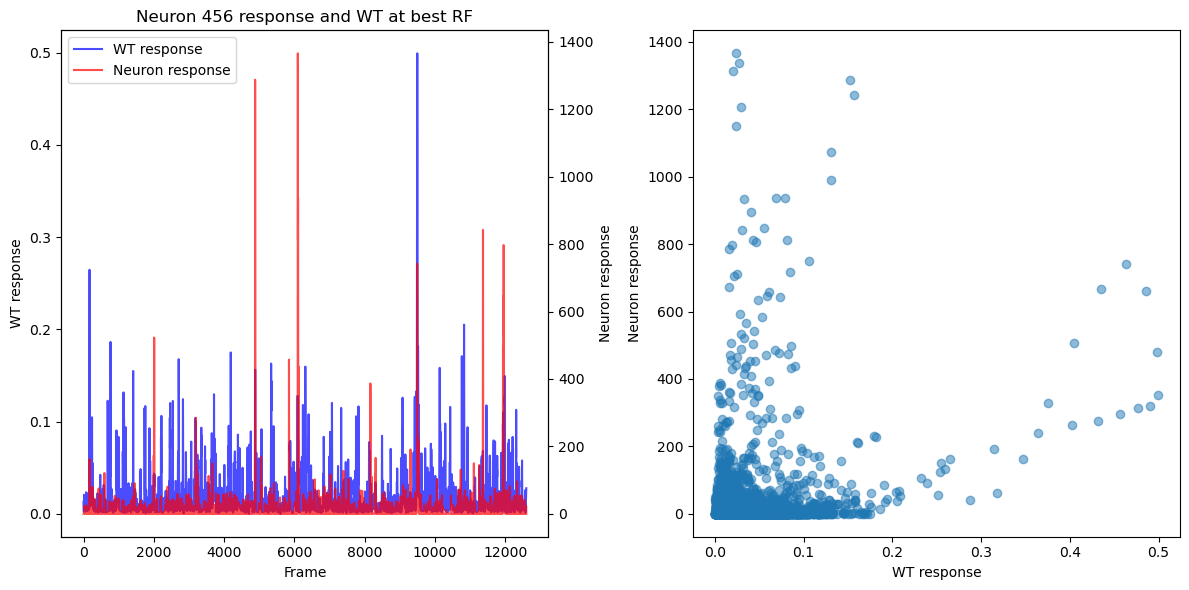

In [36]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# first subplot with two y axes
ax0 = ax[0]
ax0b = ax0.twinx()

l1 = ax0.plot(stim1, label="WT response", color="blue", alpha=0.7)
l2 = ax0b.plot(resp, label="Neuron response", color="red", alpha=0.7)

ax0.set_title(f"Neuron {ni} response and WT at best RF")
ax0.set_xlabel("Frame")
ax0.set_ylabel("WT response")
ax0b.set_ylabel("Neuron response")

# combined legend
lines = l1 + l2
labels = [line.get_label() for line in lines]
ax0.legend(lines, labels, loc="best")

# second subplot
ax[1].scatter(stim1, resp, alpha=0.5)
ax[1].set_xlabel("WT response")
ax[1].set_ylabel("Neuron response")

plt.tight_layout()
plt.show()

In [37]:
metadata

{'jobFolder': 'D:\\SynologyDriveSyncedDATA\\PROCESSED\\GBM\\GBM11\\g11_0603_r2_z225',
 'hdf5_file': 'D:\\SynologyDriveSyncedDATA\\PROCESSED\\GBM\\GBM11\\g11_0603_r2_z225\\MESMERIZE_BATCH\\dcc82b1d-d030-4bbf-b3c3-c2337aa15e3d\\dcc82b1d-d030-4bbf-b3c3-c2337aa15e3d.hdf5',
 'extractor_log': {'SeriesID': 'g11_0603_r2_z225',
  'data_dimension': (13238, 512, 512),
  'extract_image_channel': 'UG',
  'extraction_date': '2026-06-03 12:15:18.106382',
  'extractor_yamlname': 'g11_0603_r2_z225.extractor_yaml',
  'last_sourcefile': 'D:\\SynologyDriveSyncedDATA\\RAW\\GBM_TTK\\GBM11\\20260603_sorozat.mesc',
  'targetdirectory': 'D:\\SynologyDriveSyncedDATA\\PROCESSED\\GBM\\GBM11\\g11_0603_r2_z225'},
 'SeriesID': 'g11_0603_r2_z225',
 'video_file': 'D:\\SynologyDriveSyncedDATA\\PROCESSED\\Waven\\zebra_s0_d420.0_fps59.94.mp4',
 'resampled_video_file': 'D:\\SynologyDriveSyncedDATA\\PROCESSED\\Waven\\zebra_s0_d420.0_fps59.94_RESAMPLED30fps.mp4',
 'target_fps': 30,
 'PhotodiodeChannel': 'AUXi_1',
 'cnm_para